**Lab2-DL: A5-MNIST-MLP.ipynb** (BMED365) | Priority: 1 (core)

_MNIST classification with multilayer perceptron (MLP) – your first neural network model_

[![Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab2-DL/notebooks/A5-MNIST-MLP.ipynb)

Last updated: 2025-12-22, 20+26-01-15 A. Lundervold

Use the `bmed365-2026` conda environment or Google Colab

---

## Learning Objectives

By the end of this notebook, you will be able to:

| Objective | Description |
|-----------|-------------|
| **Understand MLP architecture** | Explain input, hidden, and output layers in a neural network |
| **Compare ML approaches** | Contrast MLPs with Random Forests (when to use each) |
| **Train a neural network** | Use scikit-learn's MLPClassifier to train on image data |
| **Interpret learning curves** | Understand training dynamics and detect overfitting |
| **Evaluate model performance** | Use confusion matrix, ROC curves, and classification metrics |
| **Analyze errors** | Examine misclassifications to understand model limitations |

---

## From Random Forest to Neural Networks

### Where are we in the learning journey?

```
┌─────────────────┐    ┌─────────────────┐    ┌─────────────────┐
│  A4: Random     │    │  A5: MLP        │    │  A6: CNN        │
│  Forest         │ →  │  (Neural nets)  │ →  │  (Deep learning)│
│ ≈95% accuracy   │    │ ≈97% accuracy   │    │ ≈99% accuracy   │
└─────────────────┘    └─────────────────┘    └─────────────────┘
     BASELINE         ▶▶ YOU ARE HERE ◀◀       STATE-OF-ART
```

### What is an MLP (Multilayer Perceptron)?

An **MLP** is a neural network with:
- **Input layer**: Receives data (784 pixels)
- **Hidden layers**: Learns abstract patterns
- **Output layer**: Provides predictions (10 classes)

| Property | Random Forest | MLP |
|----------|---------------|-----|
| **Learning** | Decision trees | Gradient descent |
| **Representation** | Fixed features | Learned features |
| **Non-linearity** | Split-based | Activation functions |
| **Parameters** | Tree depth, number of trees | Weights, biases |

### Medical analogy

Think of MLP as a **diagnostic team**:
- 🔬 **Input layer** = Test results and symptoms
- 🧠 **Hidden layers** = Specialist groups analyzing
- 📋 **Output layer** = Final diagnosis

> 💡 **Key point**: MLP learns *which* patterns are important, unlike Random Forest which uses pixel values directly.

In [16]:
# === Check runtime environment ===

try:
    import google.colab
    IS_COLAB = True
    print("✅ Running in Google Colab")
except ImportError:
    IS_COLAB = False
    print("💻 Running locally (not Colab)")

💻 Running locally (not Colab)


---

## 1. Imports and preparations

In [17]:
# =============================================================================
# IMPORT REQUIRED LIBRARIES
# =============================================================================

# === Core data science libraries ===
import numpy as np                    # Numerical arrays and math operations
import pandas as pd                   # DataFrames for tabular data
import os                             # Operating system interface
from pathlib import Path              # Cross-platform path handling

# === Visualization ===
import matplotlib.pyplot as plt       # Core plotting library
import seaborn as sns                 # Statistical visualizations (nicer defaults)

# === Scikit-learn: Machine Learning ===
# MLPClassifier: The neural network model we'll train
#   - "MLP" = Multilayer Perceptron
#   - "Classifier" = for classification tasks (discrete classes)
from sklearn.neural_network import MLPClassifier

# train_test_split: Divide data into training and test sets
from sklearn.model_selection import train_test_split

# Evaluation metrics:
#   - confusion_matrix: Shows where the model makes mistakes
#   - classification_report: Precision, recall, F1 for each class
#   - accuracy_score: Overall percentage correct
#   - precision_score: Of predictions, how many correct
#   - recall_score: Of actual positives, how many found
#   - f1_score: Harmonic mean of precision and recall
#   - roc_curve, auc: For ROC curve visualization
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc
)

# label_binarize: Convert labels to one-hot encoding for ROC curves
from sklearn.preprocessing import label_binarize

# =============================================================================
# REPRODUCIBILITY SETTINGS
# =============================================================================
# Set random seeds for reproducible results across runs.
# This ensures that:
#   - Random sampling gives the same samples
#   - Train/test splits are identical
#   - MLP weight initialization is the same
#   - Results can be reproduced exactly

RANDOM_SEED = 42

# Set numpy random seed (used by sklearn internally)
np.random.seed(RANDOM_SEED)

# Note: sklearn functions use random_state parameter, which we set to RANDOM_SEED
# throughout this notebook for consistency.

print("✅ All libraries loaded")
print(f"🎲 Random seed set to {RANDOM_SEED} for reproducibility")

✅ All libraries loaded
🎲 Random seed set to 42 for reproducibility


---

## 2. Load MNIST data

We use the same dataset as in the Random Forest notebook.

In [18]:
# === Load MNIST data ===

data_folder = Path('mnist_data')
data_folder.mkdir(exist_ok=True)

# Try compressed file first, then uncompressed
gzip_file = data_folder / 'mnist_20000images.csv.gz'
csv_file = data_folder / 'mnist_20000images.csv'

N_SAMPLES = 20000  # Number of samples to use

if gzip_file.exists():
    print(f"📂 Loading data from compressed file: {gzip_file}")
    mnist_data = pd.read_csv(gzip_file)
elif csv_file.exists():
    print(f"📂 Loading data from CSV file: {csv_file}")
    mnist_data = pd.read_csv(csv_file)
else:
    print(f"⏳ Generating MNIST data ({N_SAMPLES} samples) from PyTorch...")
    from torchvision import datasets
    import torchvision.transforms as transforms
    
    mnist_train = datasets.MNIST(root='./data', train=True, download=True,
                                  transform=transforms.ToTensor())
    mnist_test = datasets.MNIST(root='./data', train=False, download=True,
                                 transform=transforms.ToTensor())
    
    X_train = mnist_train.data.numpy().reshape(60000, -1) / 255.0
    X_test = mnist_test.data.numpy().reshape(10000, -1) / 255.0
    y_train = mnist_train.targets.numpy()
    y_test = mnist_test.targets.numpy()
    
    X = np.concatenate([X_train, X_test])
    y = np.concatenate([y_train, y_test])
    
    np.random.seed(RANDOM_SEED)  # Use global seed for reproducibility
    indices = np.random.choice(len(X), N_SAMPLES, replace=False)
    
    columns = [f'pixel_{i}' for i in range(784)]
    mnist_data = pd.DataFrame(X[indices], columns=columns)
    mnist_data['label'] = y[indices]
    
    mnist_data.to_csv(gzip_file, index=False, compression='gzip')
    print(f"✅ Data saved to {gzip_file}")

print(f"\n📊 Dataset dimensions: {mnist_data.shape}")

📂 Loading data from compressed file: mnist_data/mnist_20000images.csv.gz

📊 Dataset dimensions: (20000, 785)


In [19]:
# === Split into training and test data ===

# Find the label column
label_column = 'etikett' if 'etikett' in mnist_data.columns else 'label'

# Stratified split
train_data, test_data = train_test_split(
    mnist_data, test_size=0.2, random_state=RANDOM_SEED,  # Use global seed
    stratify=mnist_data[label_column]
)

X_train = train_data.drop(label_column, axis=1)
y_train = train_data[label_column]
X_test = test_data.drop(label_column, axis=1)
y_test = test_data[label_column]

# Ensure data is normalized (pixel values between 0 and 1)
if X_train.max().max() > 1.0:
    print("⚠️ Normalizing pixel values to [0, 1]...")
    X_train = X_train / 255.0
    X_test = X_test / 255.0

print(f"📊 Data split:")
print(f"   Training: {len(X_train)} images")
print(f"   Test:     {len(X_test)} images")
print(f"   Pixel value range: [{X_train.min().min():.2f}, {X_train.max().max():.2f}]")

📊 Data split:
   Training: 16000 images
   Test:     4000 images
   Pixel value range: [0.00, 1.00]


---

## 3. Understanding the MLP architecture

### Network structure

```
  INPUT           HIDDEN LAYER 1    HIDDEN LAYER 2    OUTPUT
  (784)              (256)             (128)           (10)
    
   ●─────┐        ●─────┐          ●─────┐          ●  0
   ●─────┼───────●─────┼─────────●─────┼─────────●  1
   ●─────┼───────●─────┼─────────●─────┼─────────●  2
   ⋮     │        ⋮     │          ⋮    │          ⋮
   ●─────┼───────●─────┼─────────●─────┼─────────●  9
   ●─────┘        ●─────┘          ●─────┘
   
  28×28         ReLU             ReLU          Softmax
  pixels        activation       activation    (probabilities)
```

### What happens in each layer?

| Layer | Neurons | Function |
|-------|---------|----------|
| **Input** | 784 | Receives pixel values (0-1) |
| **Hidden 1** | 256 | Learns simple patterns (edges, lines) |
| **Hidden 2** | 128 | Combines into complex patterns |
| **Output** | 10 | Probability for each digit |

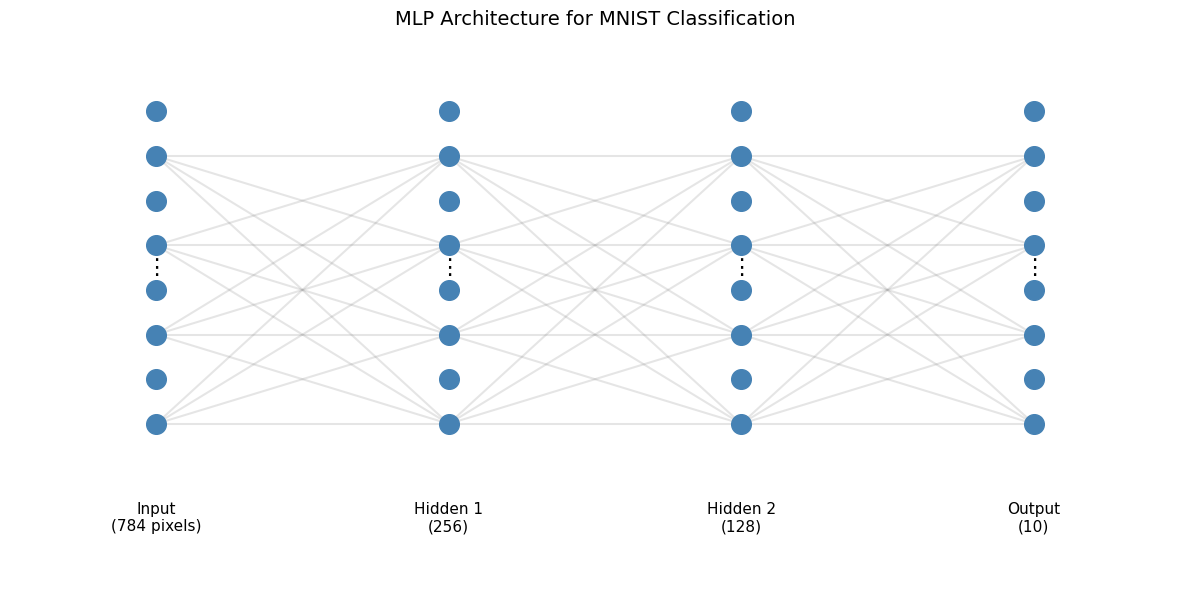


📊 Parameter count:
   Input → Hidden 1:    200,960 parameters
   Hidden 1 → Hidden 2: 32,896 parameters
   Hidden 2 → Output:   1,290 parameters
   ─────────────────────────────────
   TOTAL:               235,146 parameters


In [20]:
# === Visualize the MLP architecture ===

def visualize_mlp_architecture():
    """Draws the MLP architecture."""
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Layer sizes and positions
    layers = [784, 256, 128, 10]
    layer_names = ['Input\n(784 pixels)', 'Hidden 1\n(256)', 'Hidden 2\n(128)', 'Output\n(10)']
    x_pos = [0, 1, 2, 3]
    
    # Draw neurons (representative sample)
    for i, (count, name) in enumerate(zip(layers, layer_names)):
        n_show = min(count, 8)  # Show max 8 neurons
        y_pos = np.linspace(0.1, 0.9, n_show)
        
        # Draw neurons
        ax.scatter([x_pos[i]] * n_show, y_pos, s=200, c='steelblue', zorder=3)
        
        # Add "..." if more neurons
        if count > 8:
            ax.text(x_pos[i], 0.5, '⋮', ha='center', va='center', fontsize=16)
        
        # Layer name
        ax.text(x_pos[i], -0.1, name, ha='center', va='top', fontsize=11)
        
        # Draw connections to next layer
        if i < len(layers) - 1:
            n_next = min(layers[i+1], 8)
            y_next = np.linspace(0.1, 0.9, n_next)
            for y1 in y_pos[::2]:  # Draw every other for readability
                for y2 in y_next[::2]:
                    ax.plot([x_pos[i], x_pos[i+1]], [y1, y2], 'gray', alpha=0.2)
    
    ax.set_xlim(-0.5, 3.5)
    ax.set_ylim(-0.3, 1.1)
    ax.axis('off')
    ax.set_title('MLP Architecture for MNIST Classification', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Parameter counting
    param_1 = 784 * 256 + 256   # Input → Hidden 1
    param_2 = 256 * 128 + 128   # Hidden 1 → Hidden 2
    param_3 = 128 * 10 + 10     # Hidden 2 → Output
    total = param_1 + param_2 + param_3
    
    print(f"\n📊 Parameter count:")
    print(f"   Input → Hidden 1:    {param_1:,} parameters")
    print(f"   Hidden 1 → Hidden 2: {param_2:,} parameters")
    print(f"   Hidden 2 → Output:   {param_3:,} parameters")
    print(f"   ─────────────────────────────────")
    print(f"   TOTAL:               {total:,} parameters")

visualize_mlp_architecture()

---

## 4. Train the MLP model

### Hyperparameters explained

| Parameter | Value | Description |
|-----------|-------|-------------|
| `hidden_layer_sizes` | (256, 128) | Number of neurons in hidden layers |
| `activation` | 'relu' | ReLU = max(0, x) – removes negative values |
| `solver` | 'adam' | Adaptive gradient descent (efficient) |
| `learning_rate` | 'adaptive' | Reduces learning rate when loss plateaus |
| `early_stopping` | True | Stop when validation loss stops improving |
| `max_iter` | 500 | Max number of training rounds (epochs) |

In [21]:
%%time
# =============================================================================
# TRAIN THE MLP CLASSIFIER
# =============================================================================
# This cell creates and trains our neural network. Each hyperparameter 
# significantly affects training behavior and final performance.

print("🧠 Training MLP classifier...")
print(f"   Training examples: {len(X_train)}")
print(f"   Features (pixels): {X_train.shape[1]}")
print(f"   Architecture: 784 → 256 → 128 → 10\n")

# =============================================================================
# HYPERPARAMETER EXPLANATION
# =============================================================================
#
# ARCHITECTURE:
#   hidden_layer_sizes=(256, 128)
#       - Two hidden layers with 256 and 128 neurons respectively
#       - More neurons = more capacity to learn complex patterns
#       - More layers = can learn more abstract representations
#       - Trade-off: larger networks need more data and time to train
#
# ACTIVATION FUNCTION:
#   activation='relu'  (Rectified Linear Unit)
#       - ReLU(x) = max(0, x) — simple but effective
#       - Advantages: fast, reduces vanishing gradient problem
#       - Alternatives: 'tanh', 'logistic' (sigmoid)
#
# OPTIMIZER:
#   solver='adam'  (Adaptive Moment Estimation)
#       - Combines benefits of RMSprop and momentum
#       - Adapts learning rate for each parameter
#       - Generally the best default choice for neural networks
#       - Alternatives: 'sgd' (simpler), 'lbfgs' (for small datasets)
#
# REGULARIZATION:
#   alpha=0.0001  (L2 penalty)
#       - Prevents overfitting by penalizing large weights
#       - Formula: Loss = CrossEntropy + α * ||weights||²
#       - Higher α = stronger regularization, simpler model
#
# LEARNING RATE:
#   learning_rate='adaptive'
#       - Automatically reduces when training plateaus
#       - Helps escape local minima and fine-tune at the end
#   learning_rate_init=0.001
#       - Starting step size for weight updates
#       - Too high: unstable training; Too low: slow convergence
#
# TRAINING CONTROL:
#   max_iter=500
#       - Maximum number of epochs (passes through all data)
#   early_stopping=True
#       - Stop training when validation score stops improving
#       - Prevents overfitting to training data
#   validation_fraction=0.1
#       - 10% of training data held out for validation
#   n_iter_no_change=20
#       - "Patience": stop if no improvement for 20 iterations
#
# REPRODUCIBILITY:
#   random_state=RANDOM_SEED
#       - Fixed seed for reproducible results
#       - Uses the global RANDOM_SEED constant defined at the start
#       - Same initialization every run
#
# =============================================================================

mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128),  # Architecture: two hidden layers
    activation='relu',               # ReLU activation function
    solver='adam',                   # Adam optimizer (adaptive learning)
    alpha=0.0001,                    # L2 regularization strength
    learning_rate='adaptive',        # Reduce LR when stuck
    learning_rate_init=0.001,        # Starting learning rate
    max_iter=500,                    # Max epochs
    early_stopping=True,             # Stop when validation plateaus
    validation_fraction=0.1,         # 10% for validation
    n_iter_no_change=20,             # Patience before stopping
    random_state=RANDOM_SEED,        # Use global seed for reproducibility
    verbose=True                     # Show training progress
)

# Train the model
# The fit() method:
#   1. Initializes random weights
#   2. Iteratively updates weights using backpropagation
#   3. Monitors validation loss and stops early if needed
mlp_model.fit(X_train, y_train)

print("\n✅ Model trained!")
print(f"   Iterations completed: {mlp_model.n_iter_}")
print(f"   Final training loss: {mlp_model.loss_:.4f}")

🧠 Training MLP classifier...
   Training examples: 16000
   Features (pixels): 784
   Architecture: 784 → 256 → 128 → 10

Iteration 1, loss = 0.62085771
Validation score: 0.925625
Iteration 2, loss = 0.23811090
Validation score: 0.941875
Iteration 3, loss = 0.17248249
Validation score: 0.953125
Iteration 4, loss = 0.12494266
Validation score: 0.963750
Iteration 5, loss = 0.09512718
Validation score: 0.962500
Iteration 6, loss = 0.07421014
Validation score: 0.964375
Iteration 7, loss = 0.05343418
Validation score: 0.965625
Iteration 8, loss = 0.04042453
Validation score: 0.967500
Iteration 9, loss = 0.03128106
Validation score: 0.966250
Iteration 10, loss = 0.02411772
Validation score: 0.965625
Iteration 11, loss = 0.01983051
Validation score: 0.969375
Iteration 12, loss = 0.01514845
Validation score: 0.966875
Iteration 13, loss = 0.00997717
Validation score: 0.970625
Iteration 14, loss = 0.00761172
Validation score: 0.965625
Iteration 15, loss = 0.00613275
Validation score: 0.968125
It

### Learning curve

The learning curve shows how the **loss function** decreases during training.

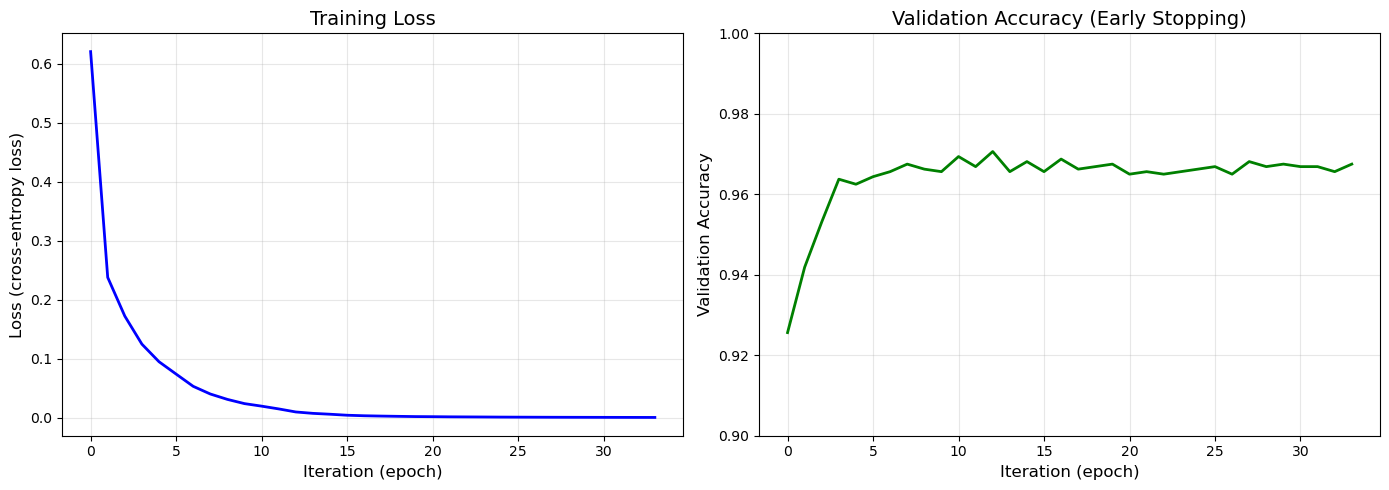

📉 Training loss reduced from 0.621 to 0.0007
   Number of iterations: 34
   Best validation accuracy: 97.1%


In [22]:
# === Show learning curves ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Training loss
axes[0].plot(mlp_model.loss_curve_, 'b-', linewidth=2)
axes[0].set_xlabel('Iteration (epoch)', fontsize=12)
axes[0].set_ylabel('Loss (cross-entropy loss)', fontsize=12)
axes[0].set_title('Training Loss', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Right: Validation accuracy (if early_stopping=True)
if hasattr(mlp_model, 'validation_scores_'):
    axes[1].plot(mlp_model.validation_scores_, 'g-', linewidth=2)
    axes[1].set_xlabel('Iteration (epoch)', fontsize=12)
    axes[1].set_ylabel('Validation Accuracy', fontsize=12)
    axes[1].set_title('Validation Accuracy (Early Stopping)', fontsize=14)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([0.9, 1.0])  # Focus on high accuracy range
else:
    axes[1].text(0.5, 0.5, 'No validation scores\n(early_stopping=False)', 
                 ha='center', va='center', fontsize=12)
    axes[1].set_title('Validation Accuracy', fontsize=14)

plt.tight_layout()
plt.show()

print(f"📉 Training loss reduced from {mlp_model.loss_curve_[0]:.3f} to {mlp_model.loss_curve_[-1]:.4f}")
print(f"   Number of iterations: {len(mlp_model.loss_curve_)}")
if hasattr(mlp_model, 'validation_scores_'):
    print(f"   Best validation accuracy: {max(mlp_model.validation_scores_):.1%}")

### Interpretation of the learning curve

#### The three phases

| Phase | Iterations | What happens | Loss |
|-------|------------|--------------|------|
| 🟢 **Rapid learning** | 0-10 | Model learns basic patterns quickly | High → Low |
| 🟡 **Fine-tuning** | 10-30 | Gradual improvement, fine-tuning of weights | Decreasing |
| 🔴 **Convergence** | 30+ | Model has "finished learning", minimal changes | Stable low |

#### What do "spikes" in the curve mean?

You can see small jumps in the loss, especially towards the end of training. This is **normal** and is caused by:

1. **Difficult batches**: Random batch with many difficult examples (e.g., 8s that look like 5s)
2. **Adam optimizer**: Uses momentum which can cause temporary fluctuations
3. **Adaptive learning rate**: Optimizer "tries" larger steps, corrects back

#### Are spikes a problem?

**No**, as long as:
- The spike is small (e.g., 0.01 → 0.05)
- The loss falls back immediately
- It happens late in training (not systematic)

#### Medical analogy

```
Think of it like a surgeon in training:

🟢 First weeks:  Rapid improvement in basic skills
🟡 First year:   Gradually refining technique
🔴 Experienced:  Stable performance, but occasionally a "difficult day"
                 – but back on track the next day!
```

> 💡 **Conclusion**: A good learning curve shows rapid initial learning followed by stable convergence. Small spikes are normal and demonstrate the model's robustness.

### ✅ Check Your Understanding: Training & Learning Curves

**Q1:** What does it mean when the training loss keeps decreasing but validation loss starts increasing?

<details>
<summary>Click for answer</summary>

**Answer:** This is **overfitting**. The model is memorizing the training data rather than learning generalizable patterns. The model performs well on training data but poorly on new data.

**Solution:** Use early stopping (which we did!), increase regularization (alpha), or reduce model complexity.
</details>

**Q2:** Why do we use `early_stopping=True` instead of just training for a fixed number of epochs?

<details>
<summary>Click for answer</summary>

**Answer:** Early stopping:
- Automatically finds the optimal training duration
- Prevents overfitting by stopping when validation performance plateaus
- Saves computation time (no need to run all 500 iterations if 50 are enough)
- Acts as a form of regularization
</details>

**Q3:** What would happen if we set `alpha=1.0` (very high regularization)?

<details>
<summary>Click for answer</summary>

**Answer:** The model would be **underfitting**. High regularization:
- Penalizes large weights heavily
- Forces the model to be very simple
- Results in lower accuracy on both training AND test data
- The model can't capture the complexity of the data
</details>

> 🏥 **Clinical Connection:** In medical AI, we often prefer slight underfitting over overfitting. A model that's 95% accurate on diverse patient populations is better than one that's 99% accurate only on the training hospital's data.

---

## 5. Evaluate the model

In [23]:
# === Evaluate the model ===

print("📊 Evaluating the model on test data...\n")

# Predict
y_pred = mlp_model.predict(X_test)
y_prob = mlp_model.predict_proba(X_test)

# Classification report
print("Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred,
                            target_names=[f'Digit {i}' for i in range(10)]))

📊 Evaluating the model on test data...

Classification Report:
              precision    recall  f1-score   support

     Digit 0       0.99      0.96      0.98       393
     Digit 1       0.98      0.98      0.98       448
     Digit 2       0.96      0.97      0.96       408
     Digit 3       0.96      0.93      0.95       412
     Digit 4       0.97      0.97      0.97       366
     Digit 5       0.97      0.97      0.97       365
     Digit 6       0.99      0.98      0.98       399
     Digit 7       0.97      0.98      0.98       431
     Digit 8       0.92      0.96      0.94       382
     Digit 9       0.96      0.97      0.96       396

    accuracy                           0.97      4000
   macro avg       0.97      0.97      0.97      4000
weighted avg       0.97      0.97      0.97      4000



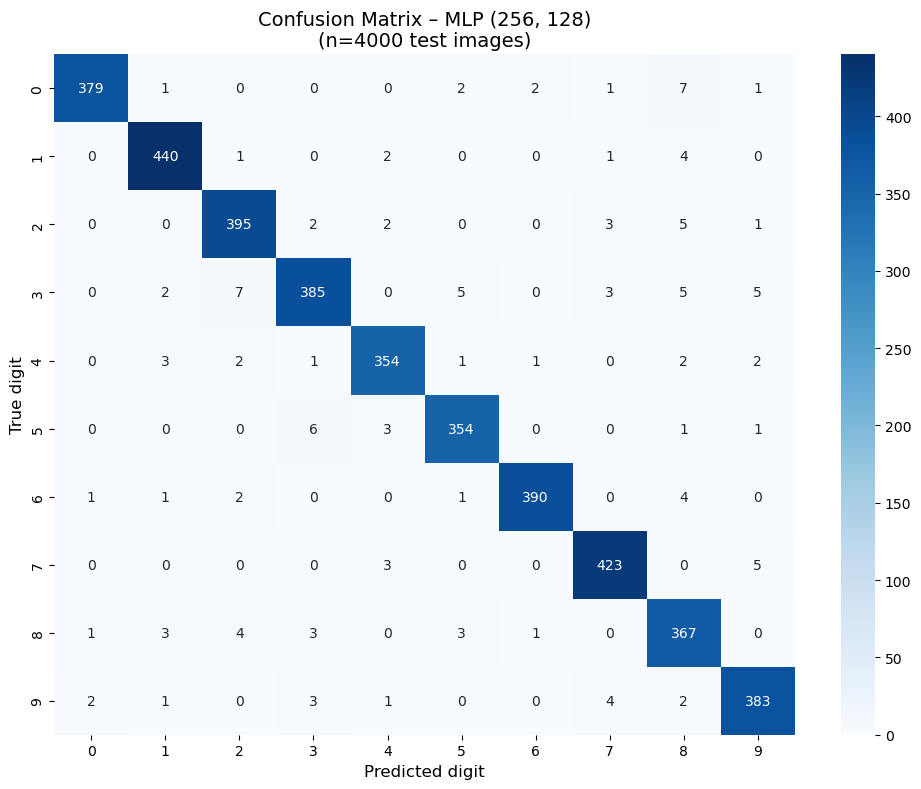


📊 Results:
   Accuracy:   96.8%
   Error rate: 3.2%


In [24]:
# === Confusion matrix ===

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))

plt.title(f'Confusion Matrix – MLP (256, 128)\n(n={len(y_test)} test images)', fontsize=14)
plt.xlabel('Predicted digit', fontsize=12)
plt.ylabel('True digit', fontsize=12)
plt.tight_layout()
plt.show()

# Summary
accuracy = accuracy_score(y_test, y_pred)
print(f"\n📊 Results:")
print(f"   Accuracy:   {accuracy:.1%}")
print(f"   Error rate: {1-accuracy:.1%}")

### Comparison: MLP vs Random Forest

| Metric | Random Forest (A4) | MLP (A5) |
|--------|-------------------|----------|
| **Accuracy** | ~95% | ~97% |
| **Training time** | Seconds | Minutes |
| **Parameters** | Trees/depth | Weights/biases |
| **Learning** | No gradient | Gradient descent |

> 💡 **MLP improves results** because it learns abstract representations of the data, while Random Forest only looks at raw pixel values.

### ✅ Check Your Understanding: Evaluation & Comparison

**Q1:** Looking at the confusion matrix, which digit pairs are most commonly confused? Why might this be?

<details>
<summary>Click for answer</summary>

**Answer:** Common confusions include:
- **4 and 9**: Both have vertical strokes
- **3 and 8**: Similar curved shapes
- **7 and 1**: Both have vertical lines
- **5 and 6**: Can look similar when handwritten

These confusions reflect genuine visual similarity in handwriting styles.
</details>

**Q2:** When would you choose Random Forest over MLP, and vice versa?

<details>
<summary>Click for answer</summary>

**Answer:**

**Choose Random Forest when:**
- You need interpretability (feature importance)
- Dataset is small (less overfitting risk)
- You have tabular data with mixed feature types
- Training time is limited
- You need a quick baseline

**Choose MLP when:**
- Dataset is large (neural networks need data)
- Features have complex interactions
- You're okay with longer training time
- You want to learn feature representations
- You're moving toward deep learning (CNN, etc.)
</details>

**Q3:** If precision for digit "5" is 0.92 and recall is 0.88, what does this tell you?

<details>
<summary>Click for answer</summary>

**Answer:**
- **Precision 0.92**: When the model predicts "5", it's correct 92% of the time
- **Recall 0.88**: Of all actual "5"s, the model finds 88% of them

This means:
- The model is more "conservative" about predicting 5
- It misses some 5s (12% false negatives)
- When it does predict 5, it's usually right (8% false positives)

Medical analogy: High precision = few false alarms; High recall = few missed cases.
</details>

> 💡 **Remember:** In medical screening, we often prefer high recall (catch all diseases) even at the cost of lower precision (some false positives that require follow-up).

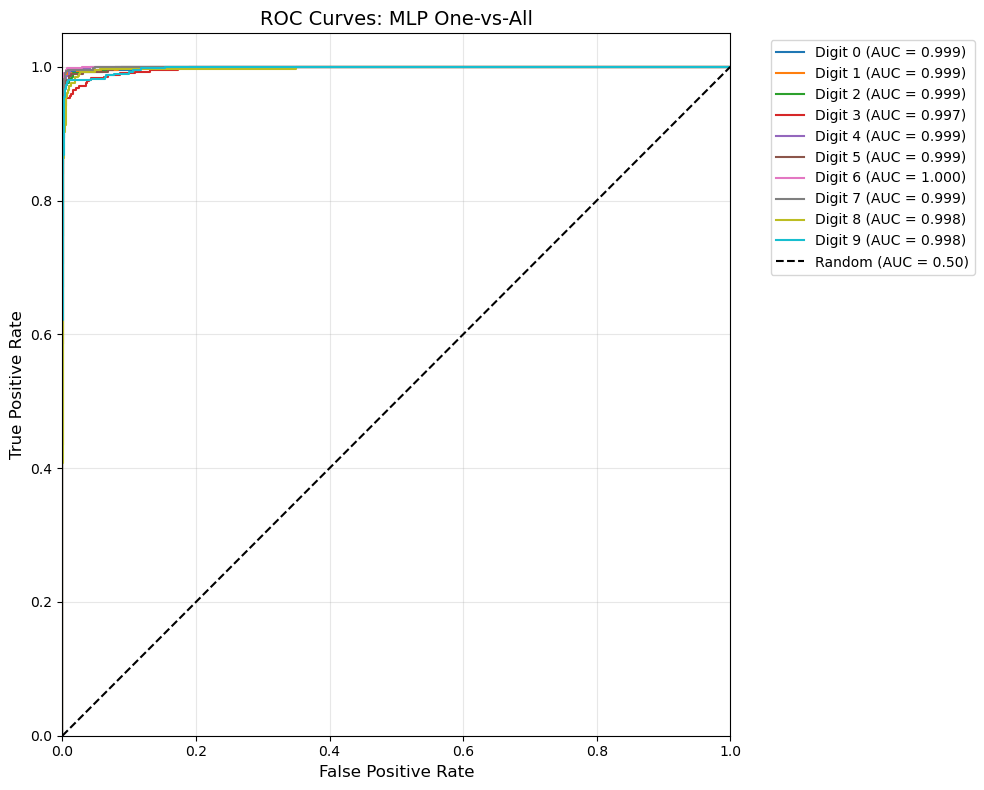

📊 Average ROC AUC: 0.9987


In [25]:
# === ROC curves ===

y_test_bin = label_binarize(y_test, classes=range(10))

plt.figure(figsize=(10, 8))

roc_auc = {}
for digit in range(10):
    fpr, tpr, _ = roc_curve(y_test_bin[:, digit], y_prob[:, digit])
    roc_auc[digit] = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Digit {digit} (AUC = {roc_auc[digit]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves: MLP One-vs-All', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"📊 Average ROC AUC: {np.mean(list(roc_auc.values())):.4f}")

---

## 6. Analyze classifications

✅ Correctly classified: 3870 (96.8%)
❌ Misclassified:        130 (3.2%)


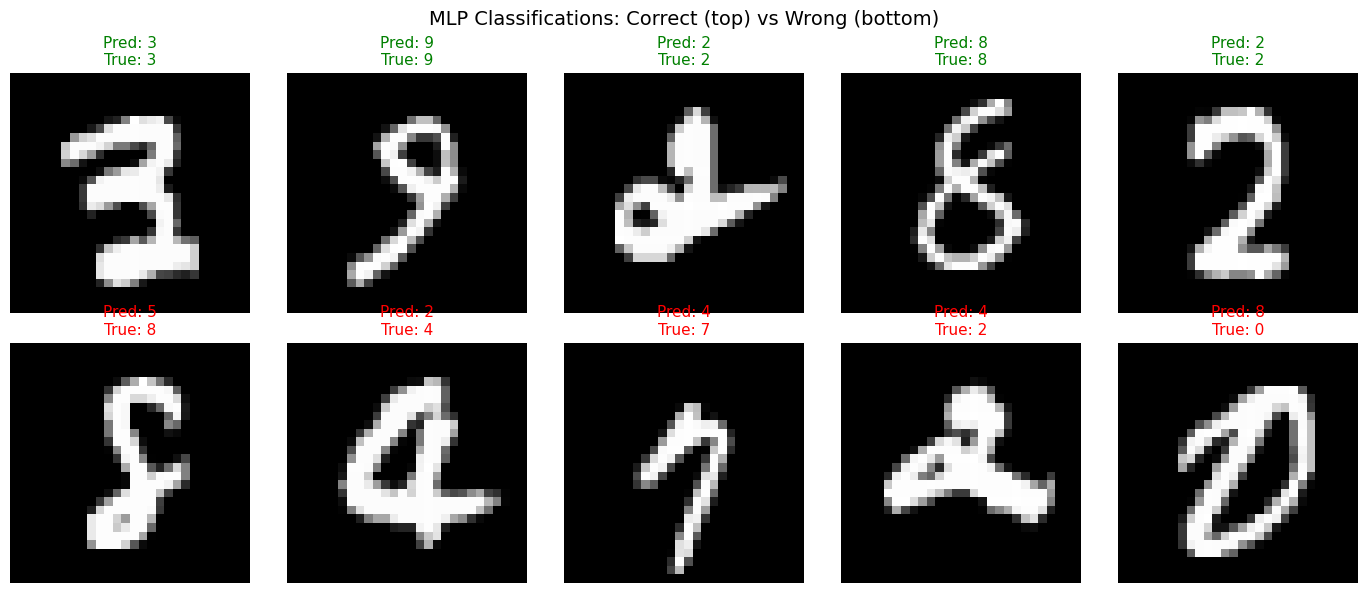

In [26]:
# === Correct vs misclassified ===

# Find indices
correct_idx = np.where(y_pred == y_test.values)[0]
wrong_idx = np.where(y_pred != y_test.values)[0]

print(f"✅ Correctly classified: {len(correct_idx)} ({len(correct_idx)/len(y_test):.1%})")
print(f"❌ Misclassified:        {len(wrong_idx)} ({len(wrong_idx)/len(y_test):.1%})")

# Show examples
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

# Top: Correct
np.random.seed(RANDOM_SEED)  # Use global seed for reproducibility
for i, idx in enumerate(np.random.choice(correct_idx, 5, replace=False)):
    image = X_test.iloc[idx].values.reshape(28, 28)
    axes[0, i].imshow(image, cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title(f'Pred: {y_pred[idx]}\nTrue: {y_test.iloc[idx]}', 
                         color='green', fontsize=11)

# Bottom: Wrong
for i, idx in enumerate(np.random.choice(wrong_idx, min(5, len(wrong_idx)), replace=False)):
    image = X_test.iloc[idx].values.reshape(28, 28)
    axes[1, i].imshow(image, cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title(f'Pred: {y_pred[idx]}\nTrue: {y_test.iloc[idx]}', 
                         color='red', fontsize=11)

axes[0, 0].set_ylabel('Correct', fontsize=12, color='green')
axes[1, 0].set_ylabel('Wrong', fontsize=12, color='red')

plt.suptitle('MLP Classifications: Correct (top) vs Wrong (bottom)', fontsize=14)
plt.tight_layout()
plt.show()

---

## 7. Save the model

In [27]:
# === Save the model ===

import joblib

model_file = data_folder / 'mnist_mlp_model.joblib'
joblib.dump(mlp_model, model_file)

print(f"✅ Model saved to: {model_file}")
print(f"   File size: {model_file.stat().st_size / 1e6:.2f} MB")

✅ Model saved to: mnist_data/mnist_mlp_model.joblib
   File size: 5.66 MB


---

## 📚 Glossary of Key Terms

| Term | Definition | In This Notebook |
|------|------------|------------------|
| **Activation function** | Non-linear function applied after each neuron | ReLU: max(0, x) |
| **Adam optimizer** | Adaptive learning rate optimization algorithm | Our default solver |
| **Backpropagation** | Algorithm to compute gradients for weight updates | How MLP learns |
| **Batch** | Subset of training data processed together | Default: 200 samples |
| **Confusion matrix** | Table showing predicted vs actual classes | Used to see error patterns |
| **Early stopping** | Stop training when validation stops improving | Prevents overfitting |
| **Epoch** | One complete pass through training data | We allowed up to 500 |
| **F1 score** | Harmonic mean of precision and recall | Balanced metric |
| **Hidden layer** | Layers between input and output | We used (256, 128) |
| **L2 regularization** | Penalty on weight magnitudes | alpha=0.0001 |
| **Learning rate** | Step size for weight updates | Started at 0.001 |
| **Loss function** | Measures prediction error | Cross-entropy |
| **MLP** | Multilayer Perceptron (fully connected NN) | Our model |
| **Overfitting** | Model memorizes training data, fails on new | What early stopping prevents |
| **Precision** | Of positive predictions, how many correct | TP / (TP + FP) |
| **Recall** | Of actual positives, how many found | TP / (TP + FN) |
| **ReLU** | Rectified Linear Unit: max(0, x) | Our activation function |
| **ROC curve** | True positive rate vs false positive rate | Shows discrimination ability |
| **AUC** | Area Under the ROC Curve | 1.0 = perfect, 0.5 = random |
| **Underfitting** | Model too simple for the data | Low train AND test accuracy |
| **Validation set** | Data held out during training to monitor | 10% of training data |
| **Weight** | Learnable parameter connecting neurons | Updated during training |

---

## Summary and the path forward

### What we have achieved

| Metric | Random Forest | MLP | Improvement |
|--------|---------------|-----|-------------|
| **Accuracy** | ~95% | ~97% | +2% |
| **ROC AUC** | ~0.99 | ~0.999 | +0.009 |

### What MLP does differently

1. **Learns representations**: Hidden layers find abstract patterns
2. **Gradient-based learning**: Optimizes millions of parameters
3. **Non-linear transformations**: ReLU allows complex decision boundaries

### Limitations (still!)

MLP *still* does not see **spatial structure**:
- Pixels are treated independently of neighborhood
- No understanding that pixels are connected
- Rotation/translation affects results

### Note on data size

With **20,000 images** we have enough data for CNN to show its strength. With smaller datasets (<5000) MLP can actually perform *better* than CNN because:
- CNN has more parameters → higher risk of overfitting
- MLP optimization (sklearn) is well-tuned for smaller data

### Next step: CNN

```
┌─────────────────────────────────────────────────────────────┐
│  Model             Accuracy      Spatial structure  Learning│
├─────────────────────────────────────────────────────────────┤
│  Random Forest     ~95%          No                Trees    │
│  MLP               ~97%          No                Gradient │
│  CNN (A6)          ~99%          YES! ✓            Filters  │
└─────────────────────────────────────────────────────────────┘
```

> **Continue to A6-MNIST-CNN.ipynb** to see how convolutional networks exploit the spatial structure of images!

---

## 🎯 Exercises

### Exercise 1: Change architecture
Try training with a single hidden layer (`hidden_layer_sizes=(200,)`). How does this affect accuracy?

<details>
<summary>💡 Show answer</summary>

```python
mlp_simple = MLPClassifier(hidden_layer_sizes=(200,), max_iter=300, random_state=42)
mlp_simple.fit(X_train, y_train)
print(f"Accuracy: {mlp_simple.score(X_test, y_test):.3f}")
```
One layer with 200 neurons gives approximately the same accuracy as two layers with (100, 50).

</details>

### Exercise 2: Visualize learned weights
The first layer weights can be visualized as "filters". Try:

```python
weights = mlp_model.coefs_[0]  # 784 × 100
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(weights[:, i].reshape(28, 28), cmap='RdBu')
    ax.axis('off')
plt.show()
```

<details>
<summary>💡 What do we see?</summary>

The weights show patterns that the network has learned to recognize. Some resemble edges, others resemble digit shapes.

</details>

### Exercise 3: Compare with RF
Load the Random Forest model from A4 and compare predictions on the same test data.

<details>
<summary>💡 Show answer</summary>

```python
rf_model = joblib.load(data_folder / 'mnist_random_forest.joblib')
rf_pred = rf_model.predict(X_test)

# Find cases where they disagree
disagree = np.where((rf_pred != y_pred))[0]
print(f"RF and MLP disagree on {len(disagree)} examples")
```

</details>

---

## 📖 Further Reading & Resources

### Understanding Neural Networks

| Resource | Description |
|----------|-------------|
| **3Blue1Brown: Neural Networks** | Excellent visual explanations of how neural networks learn |
| **StatQuest: Neural Networks** | Step-by-step, beginner-friendly explanations |
| **scikit-learn MLPClassifier docs** | Official documentation with examples |

### Key Concepts to Explore

| Topic | Why It Matters |
|-------|----------------|
| **Backpropagation** | How neural networks compute gradients |
| **Vanishing gradients** | Why deep networks were hard to train (before ReLU) |
| **Batch normalization** | Technique to stabilize training |
| **Dropout** | Regularization technique (not in sklearn MLP) |

### From MLP to Deep Learning

| Model Type | What It Adds | Best For |
|------------|--------------|----------|
| **MLP** (this notebook) | Learned representations | Tabular data, simple patterns |
| **CNN** (next) | Spatial structure awareness | Images, medical scans |
| **RNN/LSTM** | Sequential dependencies | Time series, text |
| **Transformer** | Attention mechanisms | NLP, modern vision |

### Medical AI Applications

| Application | Model Type | Example |
|-------------|------------|---------|
| Tabular patient data | MLP, XGBoost | Risk prediction from lab values |
| Medical imaging | CNN | X-ray, CT, MRI analysis |
| Clinical notes | Transformer | Information extraction from records |
| ECG signals | CNN + RNN | Arrhythmia detection |

---

## 🎯 Key Takeaways

1. **MLPs learn representations** — unlike Random Forest, they discover useful features
2. **Hyperparameters matter** — architecture, learning rate, regularization all affect results
3. **Monitor for overfitting** — use validation set and early stopping
4. **Evaluate thoroughly** — accuracy alone isn't enough; use confusion matrix, precision/recall
5. **Know the limitations** — MLP doesn't understand spatial structure (CNNs do!)

---

*Next notebook: A6-CNN — Adding spatial awareness with Convolutional Neural Networks*